<a href="https://colab.research.google.com/github/anmolgulrajani112/Machine-Learning-Project/blob/main/Machine_Learning_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Libraries imported successfully!

Files available in Colab:
['.config', 'train.csv', 'submission.csv', 'test.csv', 'dataset for mL.zip', 'sample_data']

train.csv found directly in /content. Skipping extraction.

Train file:
/content/train.csv
Test file:
/content/test.csv

DATASET LOADED
Dataset shape: (1460, 81)

First 5 rows:


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000



DATASET INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   

,0
PoolQC,1453
MiscFeature,1406
Alley,1369
Fence,1179
MasVnrType,872
FireplaceQu,690
LotFrontage,259
GarageType,81
GarageYrBlt,81
GarageFinish,81



SALE PRICE STATISTICS
count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

Selected Features:
['GrLivArea', 'OverallQual', 'BedroomAbvGr', 'FullBath', 'GarageCars', 'TotalBsmtSF', 'Neighborhood']

X shape: (1460, 7)
y shape: (1460,)


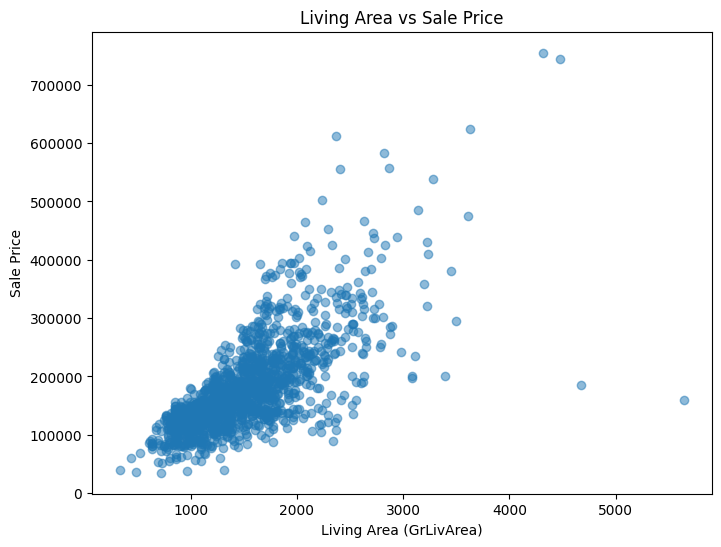


TRAIN TEST SPLIT
Training data: (1168, 7)
Testing data : (292, 7)

TRAINING MODEL
Model trained successfully!

PREDICTIONS
First 10 predictions:
Actual: $154,500.00  | Predicted: $141,065.15
Actual: $325,000.00  | Predicted: $328,470.72
Actual: $115,000.00  | Predicted: $114,188.47
Actual: $159,000.00  | Predicted: $178,840.68
Actual: $315,500.00  | Predicted: $284,311.81
Actual: $75,500.00  | Predicted: $61,934.61
Actual: $311,500.00  | Predicted: $228,294.10
Actual: $146,000.00  | Predicted: $151,493.65
Actual: $84,500.00  | Predicted: $61,934.61
Actual: $135,500.00  | Predicted: $123,145.89

MODEL EVALUATION
MAE  : $22,073.98
MSE  : $1,289,694,186.97
RMSE : $35,912.31
R²   : 0.8319


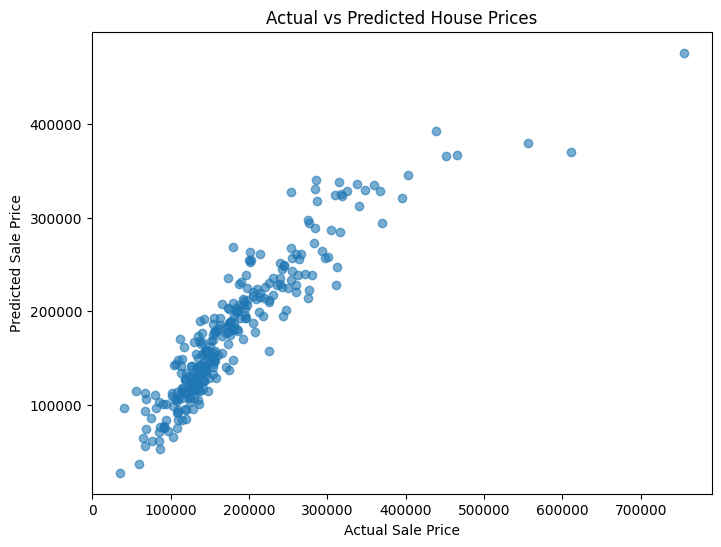


ACTUAL VS PREDICTED


,Actual Price,Predicted Price
0,154500,141065.150879
1,325000,328470.720309
2,115000,114188.473942
3,159000,178840.676403
4,315500,284311.806375
5,75500,61934.614524
6,311500,228294.096175
7,146000,151493.648320
8,84500,61934.614524
9,135500,123145.889874



Prediction file saved:
/content/house_price_predictions.csv


HOUSE PRICE PREDICTION PROJECT COMPLETED
Dataset Size       : (1460, 81)
Training Samples   : 1168
Testing Samples    : 292
MAE                : $22,073.98
RMSE               : $35,912.31
R² Score           : 0.8319

Project completed successfully!


In [ ]:

# TASK 1: HOUSE PRICE PREDICTION

# -----------------------------
# 1. IMPORT LIBRARIES
# -----------------------------

import os
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("Libraries imported successfully!")


# -----------------------------
# 2. FIND AND EXTRACT DATASET
# -----------------------------

train_path = None
test_path = None

# Check if train.csv and test.csv are already directly in /content
files_in_colab = os.listdir("/content")
print("\nFiles available in Colab:")
print(files_in_colab)

if "train.csv" in files_in_colab:
    print("\ntrain.csv found directly in /content. Skipping extraction.")
    train_path = "/content/train.csv"
    if "test.csv" in files_in_colab:
        test_path = "/content/test.csv"
else:
    # Find ZIP file automatically
    zip_files = [f for f in files_in_colab if f.lower().endswith(".zip")]

    if len(zip_files) == 0:
        raise FileNotFoundError(
            "Neither train.csv nor a ZIP file was found in /content. "
            "Please upload your dataset files to the Files section."
        )

    zip_file = "/content/" + zip_files[0]
    print("\nZIP file found:")
    print(zip_file)

    # Create extraction folder
    extract_folder = "/content/house_prices"
    os.makedirs(extract_folder, exist_ok=True)

    # Extract ZIP
    with zipfile.ZipFile(zip_file, "r") as zip_ref:
        zip_ref.extractall(extract_folder)
    print("\nDataset extracted successfully!")

    # Locate train.csv and test.csv inside the extracted directory
    for root, dirs, files in os.walk(extract_folder):
        for file in files:
            if file.lower() == "train.csv":
                train_path = os.path.join(root, file)
            if file.lower() == "test.csv":
                test_path = os.path.join(root, file)

if train_path is None:
    raise FileNotFoundError(
        "train.csv was not found."
    )

print("\nTrain file:")
print(train_path)

if test_path:
    print("Test file:")
    print(test_path)


# -----------------------------
# 3. LOAD DATASET
# -----------------------------

df = pd.read_csv(train_path)

print("\n==============================")
print("DATASET LOADED")
print("==============================")

print("Dataset shape:", df.shape)

print("\nFirst 5 rows:")
display(df.head())


# -----------------------------
# 4. DATASET INFORMATION
# -----------------------------

print("\n==============================")
print("DATASET INFORMATION")
print("==============================")

df.info()


# -----------------------------
# 5. CHECK MISSING VALUES
# -----------------------------

print("\n==============================")
print("MISSING VALUES")
print("==============================")

missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
display(missing)


# -----------------------------
# 6. TARGET VARIABLE ANALYSIS
# -----------------------------

print("\n==============================")
print("SALE PRICE STATISTICS")
print("==============================")

print(df["SalePrice"].describe())


# -----------------------------
# 7. SELECT FEATURES
# -----------------------------

features = [
    "GrLivArea",
    "OverallQual",
    "BedroomAbvGr",
    "FullBath",
    "GarageCars",
    "TotalBsmtSF",
    "Neighborhood"
]

X = df[features]
y = df["SalePrice"]

print("\nSelected Features:")
print(features)

print("\nX shape:", X.shape)
print("y shape:", y.shape)


# -----------------------------
# 8. EXPLORATORY DATA ANALYSIS
# -----------------------------

plt.figure(figsize=(8, 6))
plt.scatter(df["GrLivArea"], df["SalePrice"], alpha=0.5)
plt.xlabel("Living Area (GrLivArea)")
plt.ylabel("Sale Price")
plt.title("Living Area vs Sale Price")
plt.show()


# -----------------------------
# 9. TRAIN TEST SPLIT
# -----------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("\n==============================")
print("TRAIN TEST SPLIT")
print("==============================")

print("Training data:", X_train.shape)
print("Testing data :", X_test.shape)


# -----------------------------
# 10. PREPROCESSING
# -----------------------------

numeric_features = [
    "GrLivArea",
    "OverallQual",
    "BedroomAbvGr",
    "FullBath",
    "GarageCars",
    "TotalBsmtSF"
]

categorical_features = [
    "Neighborhood"
]

# Numeric preprocessing
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

# Categorical preprocessing
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# Combine preprocessing
preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_features),
    ("categorical", categorical_pipeline, categorical_features)
])


# -----------------------------
# 11. CREATE MACHINE LEARNING MODEL
# -----------------------------

model = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", LinearRegression())
])


# -----------------------------
# 12. TRAIN MODEL
# -----------------------------

print("\n==============================")
print("TRAINING MODEL")
print("==============================")

model.fit(X_train, y_train)
print("Model trained successfully!")


# -----------------------------
# 13. MAKE PREDICTIONS
# -----------------------------

y_pred = model.predict(X_test)

print("\n==============================")
print("PREDICTIONS")
print("==============================")

print("First 10 predictions:")
for i in range(10):
    print(
        f"Actual: ${y_test.iloc[i]:,.2f} "
        f" | Predicted: ${y_pred[i]:,.2f}"
    )


# -----------------------------
# 14. MODEL EVALUATION
# -----------------------------

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("\n==============================")
print("MODEL EVALUATION")
print("==============================")

print(f"MAE  : ${mae:,.2f}")
print(f"MSE  : ${mse:,.2f}")
print(f"RMSE : ${rmse:,.2f}")
print(f"R²   : {r2:.4f}")


# -----------------------------
# 15. ACTUAL VS PREDICTED GRAPH
# -----------------------------

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.xlabel("Actual Sale Price")
plt.ylabel("Predicted Sale Price")
plt.title("Actual vs Predicted House Prices")
plt.show()


# -----------------------------
# 16. ACTUAL VS PREDICTED TABLE
# -----------------------------

comparison = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": y_pred
})

print("\n==============================")
print("ACTUAL VS PREDICTED")
print("==============================")

display(comparison.head(10))


# -----------------------------
# 17. SAVE PREDICTIONS
# -----------------------------

comparison.to_csv(
    "/content/house_price_predictions.csv",
    index=False
)

print("\nPrediction file saved:")
print("/content/house_price_predictions.csv")


# -----------------------------
# 18. FINAL SUMMARY
# -----------------------------

print("\n")
print("==============================================")
print("HOUSE PRICE PREDICTION PROJECT COMPLETED")
print("==============================================")

print(f"Dataset Size       : {df.shape}")
print(f"Training Samples   : {len(X_train)}")
print(f"Testing Samples    : {len(X_test)}")
print(f"MAE                : ${mae:,.2f}")
print(f"RMSE               : ${rmse:,.2f}")
print(f"R² Score           : {r2:.4f}")

print("\nProject completed successfully!")